<style>
    :root{--navy:#102a43;--blue:#184e77;--teal:#2a9d8f;--gold:#e9c46a;--ink:#172033;--pale:#edf5fb}
    .hero{padding:38px 42px;border-radius:24px;color:#f8fbff;background:radial-gradient(circle at 92% 8%,rgba(255,255,255,.16) 0 8%,transparent 9%),linear-gradient(125deg,var(--navy),var(--blue) 55%,var(--teal));box-shadow:0 16px 38px #102a433d;font-family:Inter,'Segoe UI',sans-serif}.chips{display:flex;gap:8px;flex-wrap:wrap}.chips span{padding:6px 13px;border:1px solid #ffffff55;border-radius:999px;background:#ffffff20;font-size:11px;font-weight:800}.hero h1{font-size:38px;margin:18px 0 8px;color:white}.grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(210px,1fr));gap:13px;margin-top:24px}.card{padding:14px 16px;border:1px solid #ffffff44;border-radius:12px;background:#ffffff12}.section{margin:28px 0 14px;padding:16px 22px;border-radius:14px;background:linear-gradient(90deg,var(--navy),var(--blue));color:white}.section h2{margin:0;color:white}.call{padding:18px 22px;margin:14px 0;border:1px solid #c9d9e6;border-left:6px solid var(--teal);border-radius:13px;background:var(--pale);color:var(--ink);line-height:1.7}.warn{border-left-color:#e76f51;background:#fff2ed}.metric{display:inline-block;padding:10px 14px;margin:4px;border-radius:10px;background:#e5f5f2;color:#184e77;font-weight:800}table{font-size:14px}code{background:#102a4312;padding:2px 5px;border-radius:4px}</style><div class="hero"><div class="chips"><span>DEEP LEARNING</span><span>PROYECTO 1</span><span>V4 CANDIDATO</span><span>GRUPO 1 · SECCIÓN 30</span></div><h1>Monitoreo transaccional y detección de fraude</h1><p style="font-size:20px">Ingeniería causal, expertos segmentados y validación temporal</p><div class="grid"><div class="card"><b>Institución</b><br>Universidad del Valle de Guatemala</div><div class="card"><b>Curso</b><br>Deep Learning y Sistemas Inteligentes</div><div class="card"><b>Docente</b><br>Kevin Recinos</div><div class="card"><b>Integrantes</b><br>Wilson Calderón · 22018<br>Pablo Barillas · 22193</div><div class="card"><b>Dataset</b><br>IEEE-CIS Fraud Detection</div><div class="card"><b>Candidato</b><br>LightGBM expertos ProductCD</div></div></div>

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import Image, display
ROOT=Path.cwd()
if not (ROOT/'artefactos').exists(): ROOT=ROOT.parents[1]
R=json.loads((ROOT/'artefactos/v4/resultados_v4.json').read_text(encoding='utf-8'))
REC=R['modelo_v4_recomendado']; POLICY=REC['politicas'][REC['politica_recomendada']]
R['recomendacion']

'Conservar V3 como versión confirmada; V4 es el candidato congelado para la próxima cohorte.'

<div class="section"><h2>1 · Resumen ejecutivo</h2></div>

<div class="call"><b>Resultado:</b> V4 eleva AUC-PR walk-forward a 0.6175 y la ROC-AUC media a 0.9220. El candidato experto obtiene ROC-AUC 0.9012 en evaluación y mejora todas las métricas operativas con la política robusta.</div><div class="call warn"><b>Decisión científica:</b> conservar V3 como confirmada y congelar V4 para una cohorte nueva, porque el piso robusto de recall se añadió post-hoc.</div>

<div class="section"><h2>2 · Pregunta y objetivos</h2></div>

El objetivo no es maximizar accuracy, sino ordenar correctamente el fraude, mantener recall operativo, reducir falsos positivos y minimizar $C=4200FN+180FP$. Se reportan AUC-PR, ROC-AUC, precisión, recall, F1, calibración, top-K y costo.

<div class="section"><h2>3 · Datos y causalidad</h2></div>

Cada característica histórica de una transacción $t$ usa exclusivamente eventos anteriores: $$x_t^{hist}=f(\{x_j:t_j<t\}).$$ `TransactionID` se utiliza para unir tablas y `TransactionDT` para ordenar; ninguno entra como predictor directo.

In [2]:
pd.DataFrame(R['datos']['particiones']).T

,n,fraude,dt_min,dt_max
audit_train,324797.0,0.033870,86400.0,8022306.0
train,413378.0,0.035169,86400.0,10437996.0
validation,88581.0,0.034341,10438003.0,13151840.0
benchmark_historico,88581.0,0.034804,13151880.0,15811131.0


<div class="section"><h2>4 · Ingeniería V4</h2></div>

V4 añade agregados para tarjeta–dirección, tarjeta–correo, tarjeta–dispositivo y tarjeta–producto; ventanas de actividad, forma del monto, normalización temporal, patrones de ausencia, frecuencia previa y cambios de contexto.

In [3]:
pd.Series({'columnas integradas':R['datos']['columnas_integradas'],'numéricas':R['seleccion_variables']['n_numericas'],'categóricas':R['seleccion_variables']['n_categoricas'],'variables derivadas':R['identidad_y_features']['variables_ingenieria_v4']}).to_frame('valor')

,valor
columnas integradas,569
numéricas,360
categóricas,38
variables derivadas,135


<div class="section"><h2>5 · Correlación, IDs y PCA</h2></div>

Se excluyen IDs como magnitudes y se poda solo redundancia casi exacta con $|\rho_s|\ge0.999$. Una correlación marginal baja no descarta interacciones no lineales. PCA permanece como ablation: en V3 conservó 99.53% de varianza y perdió AUC-PR.

<div class="section"><h2>6 · Modelos</h2></div>

Se comparan LightGBM optimizado, XGBoost y CatBoost piloto, hard-negative mining, expertos `W/NO_W` y stacking. CatBoost/XGBoost usan presupuestos acotados después de auditar su tiempo en CPU.

<div class="section"><h2>7 · Walk-forward</h2></div>

Los tres folds entrenan solo con el pasado. LightGBM V4 aumenta AUC-PR media en 0.0366 frente a V3 y alcanza ROC-AUC media 0.9220.

In [4]:
pd.DataFrame(R['validacion_walk_forward']['detalle']).sort_values(['fold','auc_pr'],ascending=[True,False])

,fold,modelo,auc_pr,roc_auc,segundos
2,F1,XGBoost_hist,0.575377,0.907220,169.442866
0,F1,LightGBM_tuned,0.573597,0.909524,53.497066
1,F1,CatBoost_ordered,0.512947,0.887314,172.062928
3,F2,LightGBM_tuned,0.655429,0.925977,114.407194
5,F2,XGBoost_hist,0.636066,0.927275,182.276274
4,F2,CatBoost_ordered,0.602510,0.903673,110.090325
6,F3,LightGBM_tuned,0.623542,0.930426,162.062218
8,F3,XGBoost_hist,0.575744,0.922822,196.784732
7,F3,CatBoost_ordered,0.475196,0.890921,127.692053


<div class="section"><h2>8 · Evidencia walk-forward</h2></div>

La mejora se sostiene especialmente en F3, el corte más cercano al final y más sensible a deriva.

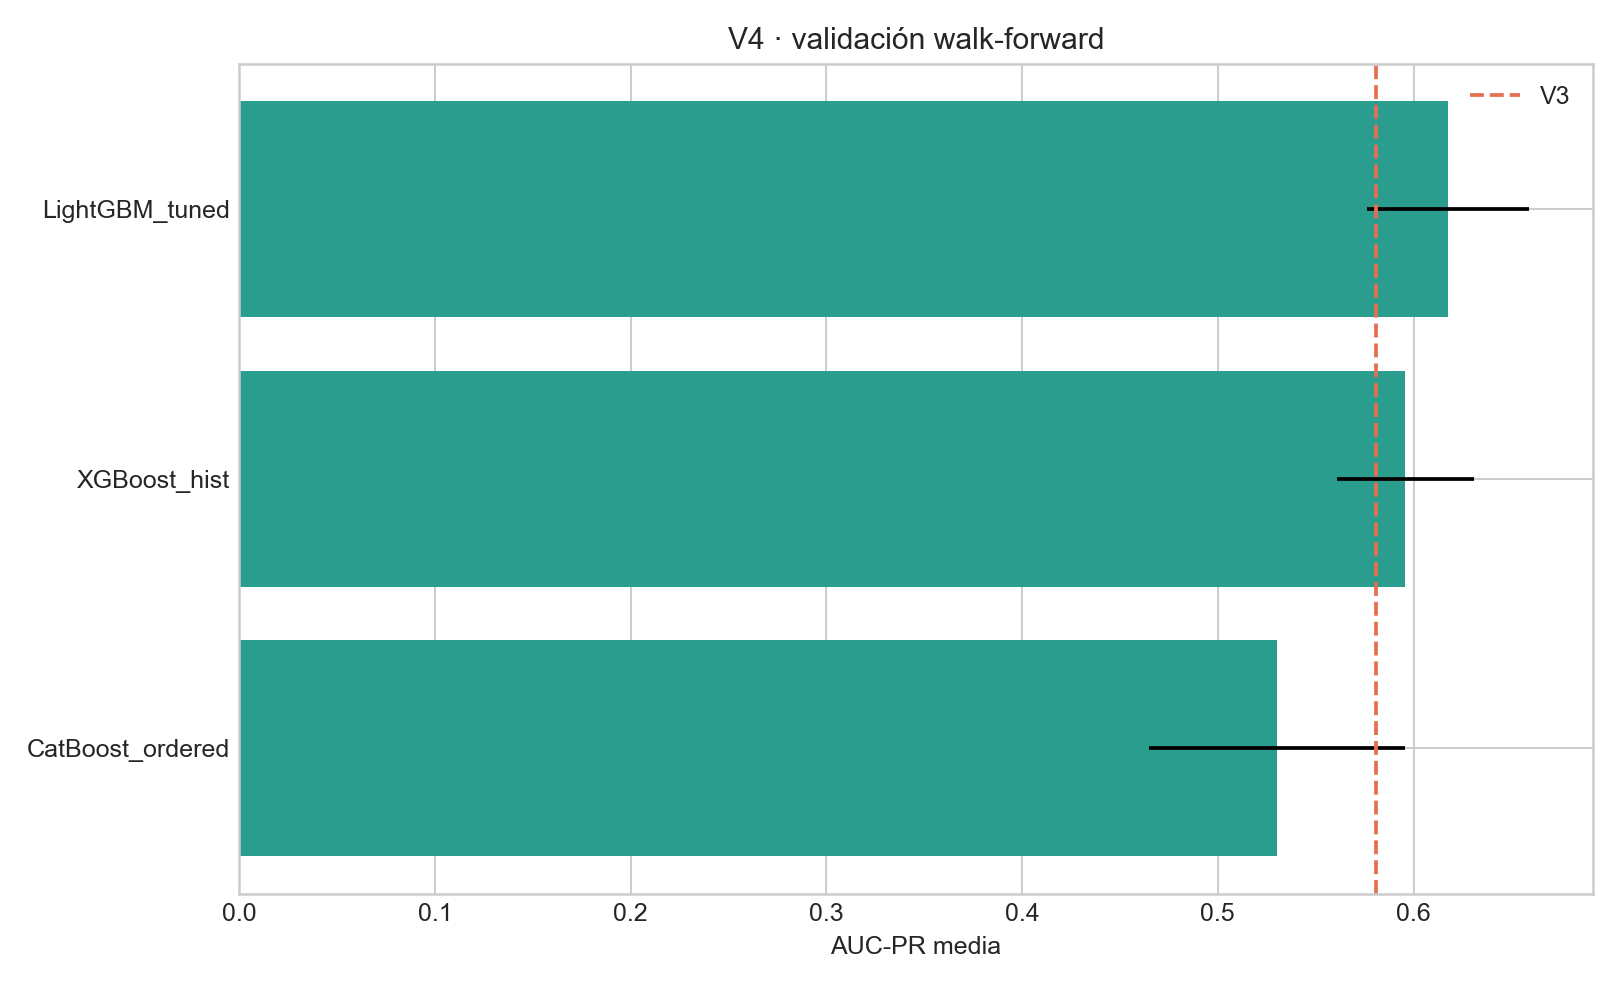

In [5]:
display(Image(filename=str(ROOT/'evidencia/figuras/v4/01_walk_forward_v4.png')))

<div class="section"><h2>9 · Selección del candidato</h2></div>

La selección usa 50–60% de validación, antes de calibración, umbral y evaluación. El experto por ProductCD gana; el stacking queda segundo y pierde ROC-AUC en evaluación.

In [6]:
pd.DataFrame(REC['seleccion'])

,modelo,columna,auc_pr_seleccion,roc_auc_seleccion
0,LightGBM_expertos_ProductCD,score_segment_lgb,0.607841,0.921349
1,Stacking_experimental,score_stack_raw,0.600705,0.901641
2,LightGBM_hard_negative,score_hard_lgb,0.588492,0.919721
3,XGBoost_piloto,score_xgboost,0.582599,0.932448
4,LightGBM_global,score_lgb,0.581971,0.918661
5,CatBoost_piloto,score_catboost,0.485534,0.904987


<div class="section"><h2>10 · Calibración</h2></div>

La calibración sigmoide del candidato reduce Brier y ECE en su bloque reservado. Calibrar no cambia AUC-PR/ROC-AUC; mejora la interpretación probabilística y la estabilidad del umbral.

In [7]:
pd.Series(REC['calibracion']).to_frame('valor')

,valor
brier_raw,0.024475
brier_calibrado,0.023674
ece_raw,0.015613
ece_calibrado,0.006010


<div class="section"><h2>11 · Políticas de umbral</h2></div>

Se conservan tres políticas. La robusta exige recall ≥0.75 en selección; es útil por el costo alto de FN, pero se etiqueta post-hoc.

In [8]:
pd.DataFrame({k:v['evaluacion'] for k,v in REC['politicas'].items()}).T[['threshold','precision','recall','f1','costo_q','alertas_por_100k']]

,threshold,precision,recall,f1,costo_q,alertas_por_100k
balanceado_recall_070,0.077677,0.248182,0.689394,0.364973,665460.0,8278.145695
robusto_recall_075_post_hoc,0.056639,0.202405,0.765152,0.320127,605520.0,11265.803733
economico,0.036119,0.141975,0.813131,0.241742,661080.0,17068.031306


<div class="section"><h2>12 · Comparación V3–V4</h2></div>

En el bloque final comparable, la política robusta domina AUC-PR, ROC-AUC, precisión, recall, F1 y costo. El IC pareado de AUC-PR excluye cero.

In [9]:
pd.DataFrame({'V3':REC['comparacion_v3_evaluacion']['v3'],'V4':POLICY['evaluacion']}).T[['auc_pr','roc_auc','precision','recall','f1','costo_q']]

,auc_pr,roc_auc,precision,recall,f1,costo_q
V3,0.444963,0.890000,0.162710,0.709596,0.264720,743280.0
V4,0.549070,0.901214,0.202405,0.765152,0.320127,605520.0


<div class="section"><h2>13 · Benchmark histórico</h2></div>

El benchmark reutilizado confirma consistencia descriptiva: AUC-PR 0.5592 y ROC-AUC 0.9013. No decide selección ni promoción.

In [10]:
pd.Series(POLICY['benchmark_historico']).to_frame('valor')

,valor
auc_pr,5.591558e-01
roc_auc,9.012684e-01
brier,2.135081e-02
threshold,5.663912e-02
precision,2.151684e-01
recall,7.398638e-01
f1,3.333821e-01
tn,7.717800e+04
fp,8.320000e+03
fn,8.020000e+02


<div class="section"><h2>14 · Curvas PR</h2></div>

V4 mejora el ranking frente a V3 en el benchmark histórico, aunque la confirmación exige datos nuevos.

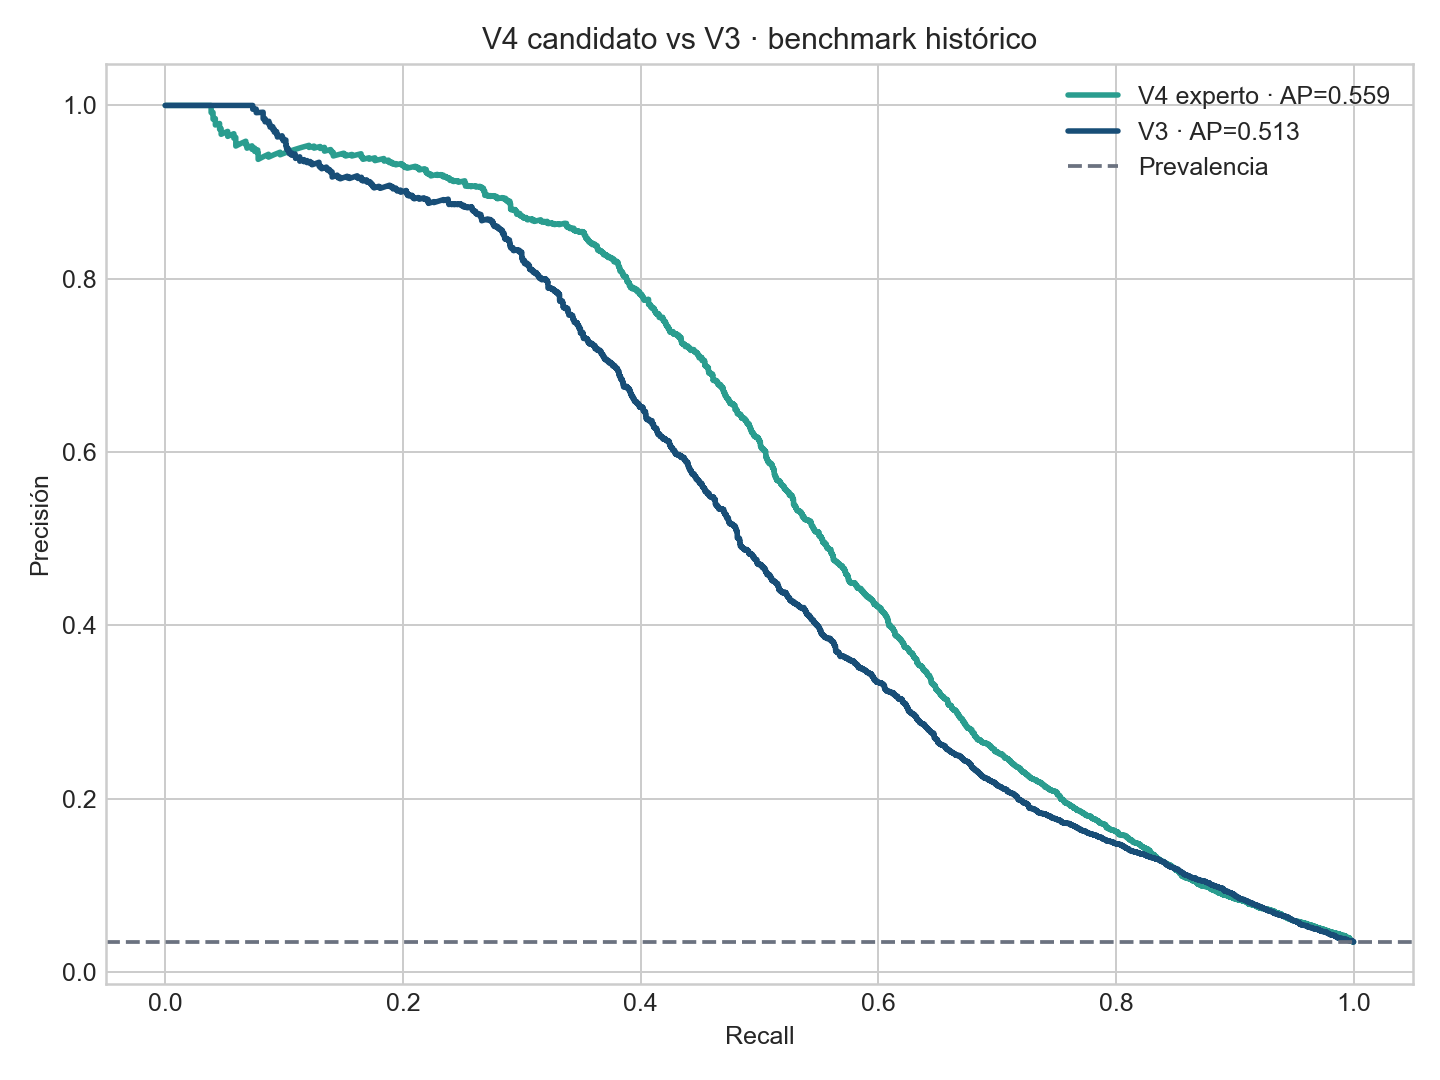

In [11]:
display(Image(filename=str(ROOT/'evidencia/figuras/v4/07_curvas_pr_candidato_v4.png')))

<div class="section"><h2>15 · Capacidad top-K</h2></div>

Al revisar 1% de mayor riesgo, precision@K supera 0.90. Esta es la afirmación correcta de una métrica ≥0.90; no equivale a precisión poblacional.

In [12]:
pd.DataFrame(R['metricas_top_k_candidato'])

,tasa_revision,k,precision_at_k,recall_at_k
0,0.001,88,1.000000,0.028544
1,0.005,442,0.947964,0.135907
2,0.010,885,0.907345,0.260461
3,0.020,1771,0.739130,0.424586
4,0.050,4429,0.419282,0.602335


<div class="section"><h2>16 · Deriva</h2></div>

La validación adversarial obtiene ROC-AUC 1.0, dominada por tiempo y frecuencias acumulativas. Esto evidencia separación temporal y obliga a monitorear deriva, no perfección del detector.

In [13]:
pd.DataFrame(R['deriva_adversarial']['top_variables'])

,variable,ganancia
0,day_index,1.690521e+06
1,weekday_cos,2.389418e+03
2,freq_prior_addr2,1.558171e+03
3,month_proxy,1.464784e+03
4,hour_cos,6.533408e+02
5,D1_minus_day,3.223270e+02
6,freq_prior_productcd,1.260177e+02
7,weekday_sin,7.924932e+01
8,share_prior_addr1,7.011898e+01
9,D10_minus_day,1.913370e+01


<div class="section"><h2>17 · Qué no funcionó</h2></div>

CatBoost piloto fue inestable; XGBoost no superó LightGBM; el stacking redujo ROC-AUC; PCA perdió señal en V3. Conservar resultados negativos evita justificar complejidad sin beneficio.

<div class="section"><h2>18 · Decisión</h2></div>

V4 queda congelada como candidato superior post-hoc. V3 permanece confirmada hasta evaluar V4 sin cambios en una cohorte temporal nueva. No se ajustarán variables, modelos o umbrales después de ver esa cohorte.

In [14]:
R['decision_v4']

{'estado': 'candidato_superior_post_hoc_requiere_cohorte_nueva',
 'promocion_confirmatoria': False,
 'razon': 'La política recall>=0.75 domina a V3, pero fue añadida después de observar la primera evaluación V4.',
 'siguiente_paso': 'Congelar esta política y validarla sin cambios en una cohorte temporal nueva.'}

<div class="section"><h2>19 · Uso responsable</h2></div>

El sistema prioriza revisión humana. No determina culpabilidad ni bloquea operaciones automáticamente. Antes de producción se requieren privacidad, seguridad, explicabilidad, monitoreo, costos reales y apelación.

<div class="section"><h2>20 · Reproducibilidad</h2></div>

La fuente única es `artefactos/v4/resultados_v4.json`. El pipeline, postprocesamiento, construcción y auditoría están separados para conservar trazabilidad.

<div class="section"><h2>Referencias APA 7</h2></div>

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *KDD*, 2623–2631.

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD*, 785–794.

IEEE Computational Intelligence Society. (2019). *IEEE-CIS Fraud Detection* [Conjunto de datos]. Kaggle.

Ke, G., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *NeurIPS, 30*.

Prokhorenkova, L., et al. (2018). CatBoost: Unbiased boosting with categorical features. *NeurIPS, 31*.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating imbalanced classifiers. *PLOS ONE, 10*(3), e0118432.

**Declaración de IA.** Se utilizó asistencia para código, redacción, visualización y auditoría. Los autores ejecutaron y verificaron los resultados y asumen responsabilidad por sus conclusiones.